In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,recall_score,f1_score,precision_score

In [4]:
df=pd.read_csv('anime.csv')
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [5]:
df.shape

(12294, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


#### Hence from the information, the given dataset has 3 numerial columns and 4 categorical columns

In [7]:
#### Getting the statistical information of the numerical columns
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [8]:
### Checking for missing values
df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

#### The missing values are present in both numerical and categorical columns in the given dataset
#### Hence, we replace the missing values in the numerical coumns with mean and categorical columhs with modem

In [9]:
### For numerical columns
df1 = df.fillna(df.mean(numeric_only=True))

In [10]:
df1.isnull().sum()

anime_id     0
name         0
genre       62
type        25
episodes     0
rating       0
members      0
dtype: int64

In [11]:
### For categorical columns
for col in df1.select_dtypes(include=['object']).columns:
    df1[col] = df1[col].fillna(df1[col].mode()[0]) 

In [12]:
df1.isnull().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

In [13]:
#### Checking for duplicates
df.duplicated().sum()

np.int64(0)

#### Hence the missing values are replaced and there are no duplicate values

### Exploring the dataset to understand its structure and attributes

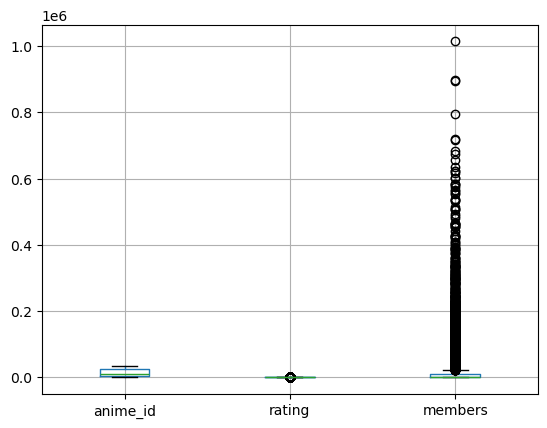

In [14]:
# Checking for outliers
df.boxplot()
plt.show()

In [15]:
def outlier_cappping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[column]=df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(['int','float']).columns:
    outlier_cappping(df,col)

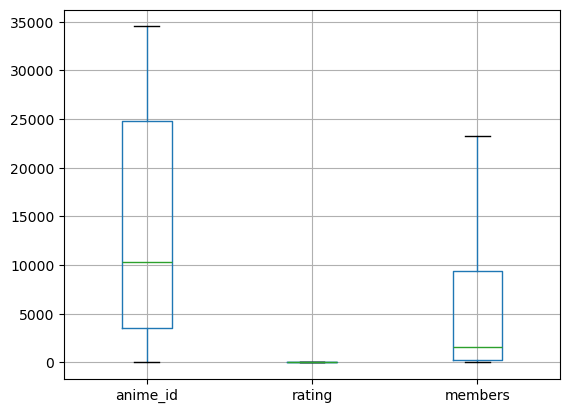

In [16]:
df.boxplot()
plt.show()

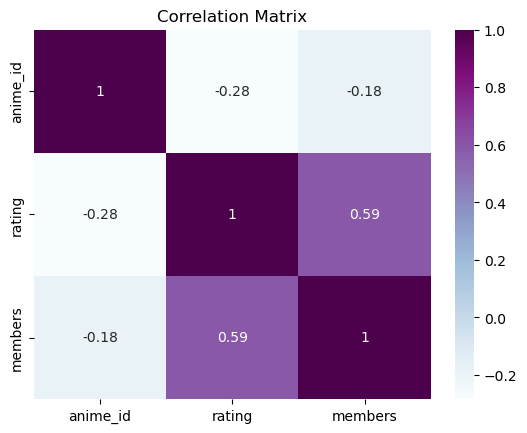

In [17]:
#### Plotting corrleatin matrix to find the relationship between the features
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='BuPu')
plt.title('Correlation Matrix')
plt.show()

### 2.Feature Extraction:

Decide on the features that will be used for computing similarity (e.g., genres, user ratings).

Convert categorical features into numerical representations if necessary.

Normalize numerical features if required.

In [18]:
df2=df1.drop(['anime_id','name','genre'],axis='columns')
df2.head()

,type,episodes,rating,members
0,Movie,1,9.37,200630
1,TV,64,9.26,793665
2,TV,51,9.25,114262
3,TV,24,9.17,673572
4,TV,51,9.16,151266


In [19]:
### Converting categorical to numerical
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df2['type'] = le.fit_transform(df2['type'])
df2.head(3)

,type,episodes,rating,members
0,0,1,9.37,200630
1,5,64,9.26,793665
2,5,51,9.25,114262


In [20]:
df2.isnull().sum().sum()

np.int64(0)

In [21]:
### Firstly replacing the unknowns with NaN value, then REpalcing these NaN vaules with median
## using pd.to_numeric which helps to convert the data with different datatypes to numeric type
#### "coerce"-it replaces unparsable values with NaN
for col in df2.columns:
    df2[col] = pd.to_numeric(df2[col], errors='coerce') 
    df2[col].fillna(df2[col].median(), inplace=True) 

In [22]:
#### Hence there are no missing values in the df2 set

#### Normalizing Numerical features

In [23]:
min_max=MinMaxScaler()

num_col = ['episodes','rating','members']
scaled_data=min_max.fit_transform(df2[num_col])
scaled_data

array([[0.00000000e+00, 9.24369748e-01, 1.97872202e-01],
       [3.46725371e-02, 9.11164466e-01, 7.82770102e-01],
       [2.75178866e-02, 9.09963986e-01, 1.12689267e-01],
       ...,
       [1.65107320e-03, 3.85354142e-01, 2.11063682e-04],
       [0.00000000e+00, 3.97358944e-01, 1.67667411e-04],
       [0.00000000e+00, 4.54981993e-01, 1.35120208e-04]])

In [24]:
### Creating a dataframe of this Scaled data
scaled_data=pd.DataFrame(scaled_data,columns=['Episodes','Rating','Members'])
scaled_data.head()

,Episodes,Rating,Members
0,0.000000,0.924370,0.197872
1,0.034673,0.911164,0.782770
2,0.027518,0.909964,0.112689
3,0.012658,0.900360,0.664325
4,0.027518,0.899160,0.149186


In [25]:
main_df=pd.concat([df2,scaled_data],axis=1)
main_df.head()

,type,episodes,rating,members,Episodes,Rating,Members
0,0,1.0,9.37,200630,0.000000,0.924370,0.197872
1,5,64.0,9.26,793665,0.034673,0.911164,0.782770
2,5,51.0,9.25,114262,0.027518,0.909964,0.112689
3,5,24.0,9.17,673572,0.012658,0.900360,0.664325
4,5,51.0,9.16,151266,0.027518,0.899160,0.149186


In [26]:
main_df = main_df.drop(['episodes', 'rating', 'members'], axis='columns')
main_df.head()

,type,Episodes,Rating,Members
0,0,0.000000,0.924370,0.197872
1,5,0.034673,0.911164,0.782770
2,5,0.027518,0.909964,0.112689
3,5,0.012658,0.900360,0.664325
4,5,0.027518,0.899160,0.149186


#### Recommendation System:
##### Design a function to recommend anime based on cosine similarity.
##### Given a target anime, recommend a list of similar anime based on cosine similarity scores.
##### Experiment with different threshold values for similarity scores to adjust the recommendation list size.
##### Analyze the performance of the recommendation system and identify areas of improvement.

    
Design a function to recommend anime based on cosine similarity.

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [28]:
df = df[['name', 'genre']].dropna()

In [29]:
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['genre'])

In [30]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [31]:
def recommend_anime(title, df, cosine_sim, threshold=0.3, top_n=10):
    if title not in df['name'].values:
        return f"Anime '{name}' not found in dataset."

    idx = df[df['name'] == title].index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Filter scores above threshold and sort
    sim_scores = [x for x in sim_scores if x[1] >= threshold and x[0] != idx]
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[:top_n]

    anime_indices = [i[0] for i in sim_scores]
    return df['name'].iloc[anime_indices].tolist()

#### Given a target anime, recommend a list of similar anime based on cosine similarity scores.

In [33]:
recommend_anime("Naruto", df, cosine_sim, threshold=0.2, top_n=5)

['Boruto: Naruto the Movie',
 'Naruto: Shippuuden',
 'Boruto: Naruto the Movie - Naruto ga Hokage ni Natta Hi',
 'Naruto x UT',
 'Naruto: Shippuuden Movie 4 - The Lost Tower']

#### Experiment with different threshold values for similarity scores to adjust the recommendation list size.

In [35]:
for t in [0.1, 0.2, 0.3, 0.4]:
    print(f"Threshold: {t}")
    print(recommend_anime("Naruto", df, cosine_sim, threshold=t))
    print("-"*30)

Threshold: 0.1
['Boruto: Naruto the Movie', 'Naruto: Shippuuden', 'Boruto: Naruto the Movie - Naruto ga Hokage ni Natta Hi', 'Naruto x UT', 'Naruto: Shippuuden Movie 4 - The Lost Tower', 'Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsugu Mono', 'Naruto Shippuuden: Sunny Side Battle', 'Naruto Soyokazeden Movie: Naruto to Mashin to Mitsu no Onegai Dattebayo!!', 'Kyutai Panic Adventure!', 'Naruto: Shippuuden Movie 6 - Road to Ninja']
------------------------------
Threshold: 0.2
['Boruto: Naruto the Movie', 'Naruto: Shippuuden', 'Boruto: Naruto the Movie - Naruto ga Hokage ni Natta Hi', 'Naruto x UT', 'Naruto: Shippuuden Movie 4 - The Lost Tower', 'Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsugu Mono', 'Naruto Shippuuden: Sunny Side Battle', 'Naruto Soyokazeden Movie: Naruto to Mashin to Mitsu no Onegai Dattebayo!!', 'Kyutai Panic Adventure!', 'Naruto: Shippuuden Movie 6 - Road to Ninja']
------------------------------
Threshold: 0.3
['Boruto: Naruto the Movie', 'Naruto: Shippuuden', 'Bor

#### Analyzing the performance of the recommendation system and identify areas of improvement.

In [38]:
###Splitting the dataset into train and test
features=main_df.drop('type', axis='columns')
target=main_df['type']

In [40]:
x_train, x_test, y_train, y_test = train_test_split(features,target, test_size=0.2, random_state=42)

In [41]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(x_train, y_train)


RandomForestClassifier(random_state=42)

In [42]:
y_pred = clf.predict(x_test)
y_pred

array([3, 5, 5, ..., 0, 4, 5])

In [44]:
### Calculating the evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Evaluation Metrics:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Evaluation Metrics:
Accuracy: 0.5978039853599024
Precision: 0.5758896830450527
Recall: 0.5978039853599024
F1 Score: 0.5839914950521757


#### Analysis of the system along with identifying the performance


##### Precision: Good if we only want to recommend anime the user is likely to enjoy.
##### Recall: Can be improved if we're missing good suggestions — we can  try boosting models like XGBoost.
##### F1 Score: A balance between the two. 
##### Feature limitations - we can add more features like user age, tags, reviews 
##### we can prefer content-based filtering (e.g., genre/type) 
##### Trying XGBoost, tune hyperparameters ,etc 
might be helpful in contributing to increase the performance od the modelm

#### Interview Questions:
1. Can you explain the difference between user-based and item-based collaborative filtering?
What is Collaborative Filtering?